# Data loading
This notebook load and inspects UK passenger rail usage data
from the office of Rail and Road (ORR)


## Process of work in progress

In [2]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd

file_a = "../data/raw/fle100a(FLE0100a).csv"
file_b = "../data/raw/fle100b(FLE0100b).csv"

df_a = pd.read_csv(file_a)
df_b = pd.read_csv(file_b)

In [4]:
df_a.head
df_a.shape
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 22 columns):
 #   Column                                                                                                    Non-Null Count  Dtype  
---  ------                                                                                                    --------------  -----  
 0   Table FLE0100a: UK Ship Register annual statistics and commercial data comparison: 2003 to 2025 [note 8]  29 non-null     object 
 1   Unnamed: 1                                                                                                24 non-null     object 
 2   Unnamed: 2                                                                                                24 non-null     object 
 3   Unnamed: 3                                                                                                24 non-null     object 
 4   Unnamed: 4                                                                        

In [5]:
df_b.head
df_b.shape
df_b.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 8 columns):
 #   Column                                                                                                                       Non-Null Count  Dtype  
---  ------                                                                                                                       --------------  -----  
 0   Table FLE0100b: UK Ship Register monthly data for ships joining and leaving UK Ship Register: January 2015 to February 2026  272 non-null    object 
 1   Unnamed: 1                                                                                                                   269 non-null    object 
 2   Unnamed: 2                                                                                                                   269 non-null    object 
 3   Unnamed: 3                                                                                                               

In [6]:
df_a.isna().sum()

Table FLE0100a: UK Ship Register annual statistics and commercial data comparison: 2003 to 2025 [note 8]     4
Unnamed: 1                                                                                                   9
Unnamed: 2                                                                                                   9
Unnamed: 3                                                                                                   9
Unnamed: 4                                                                                                   9
Unnamed: 5                                                                                                   9
Unnamed: 6                                                                                                   9
Unnamed: 7                                                                                                   9
Unnamed: 8                                                                                                   9
U

In [7]:
df_b.isna().sum()

Table FLE0100b: UK Ship Register monthly data for ships joining and leaving UK Ship Register: January 2015 to February 2026      0
Unnamed: 1                                                                                                                       3
Unnamed: 2                                                                                                                       3
Unnamed: 3                                                                                                                       3
Unnamed: 4                                                                                                                       3
Unnamed: 5                                                                                                                       3
Unnamed: 6                                                                                                                     272
Unnamed: 7                                                                         

## Initial Data Inspection

Two related datasets were loaded from the UK Ship Register statistics published
by GOV.UK. The datasets contain multi-row headers and missing values, which are
common in public-sector data and will be addressed in subsequent steps.

## EDA – Annual UK Ship Register Statistics (FLE0100a)

This section explores long-term trends in the UK Ship Register using annual
statistics, focusing on changes in the number of registered merchant vessels
over time.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_a = pd.read_csv(
    "../data/raw/fle100a(FLE0100a).csv",
    skiprows=6,
    header=None
)

df_a.columns = df_a.iloc[0]
df_a = df_a.iloc[1:].reset_index(drop=True)

df_a = df_a.loc[:, ~df_a.columns.astype(str).str.contains("^Unnamed")]

df_a.columns = (
    df_a.columns.astype(str)
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("[^a-z0-9_]", "", regex=True)
)


In [4]:
df_plot = df_a[
    ["at_year_end", "mca_all_merchant_vessels_note_6"]
].copy()

In [5]:
df_plot["vessel_count"] = pd.to_numeric(
    df_plot["mca_all_merchant_vessels_note_6"]
    .astype(str)
    .str.replace(",", "", regex=False),
    errors="coerce"
)


In [6]:
df_plot = df_plot.dropna(subset=["vessel_count"])
print(df_plot.shape)

(23, 3)


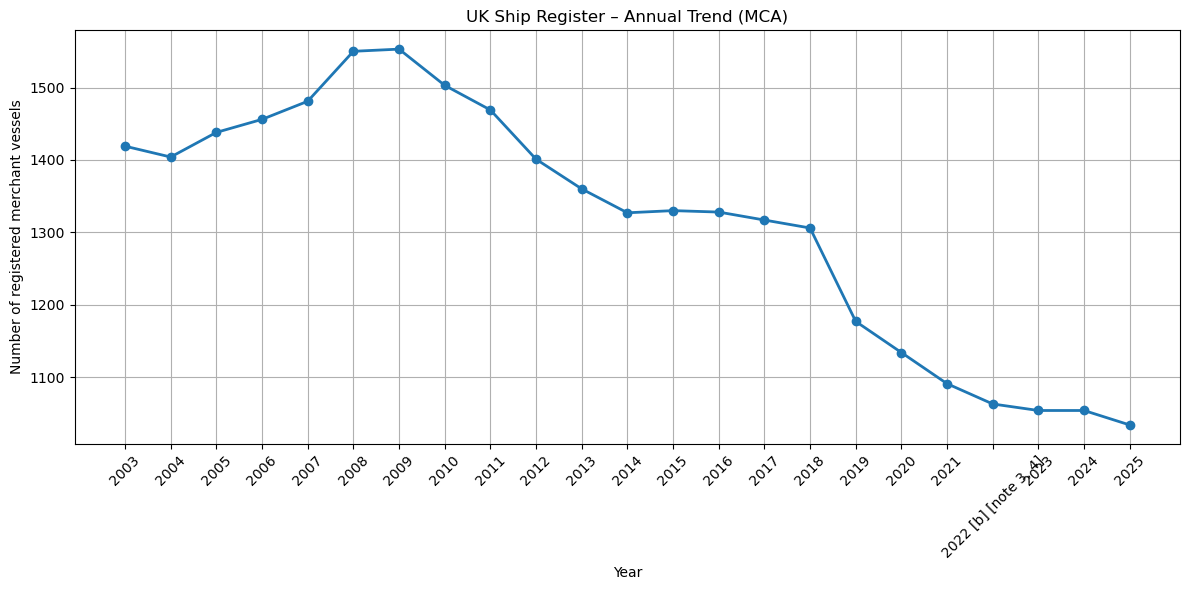

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(
    df_plot["at_year_end"],
    df_plot["vessel_count"],
    marker="o",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Number of registered merchant vessels")
plt.title("UK Ship Register – Annual Trend (MCA)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()